In [1]:
import pandas as pd

df = pd.read_csv("Reviews.csv")

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


In [3]:
df[['Score', 'Summary', 'Text']].head(10)

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...
5,4,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,5,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,5,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,5,Yay Barley,Right now I'm mostly just sprouting this so my...
9,5,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [4]:
df['Score'].value_counts().sort_index()

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [5]:
df = df[df['Score'] != 3]

df['Sentiment'] = df['Score'].apply(
    lambda x: 1 if x >= 4 else 0
)

df[['Score', 'Sentiment', 'Text']].head(10)

,Score,Sentiment,Text
0,5,1,I have bought several of the Vitality canned d...
1,1,0,Product arrived labeled as Jumbo Salted Peanut...
2,4,1,This is a confection that has been around a fe...
3,2,0,If you are looking for the secret ingredient i...
4,5,1,Great taffy at a great price. There was a wid...
5,4,1,I got a wild hair for taffy and ordered this f...
6,5,1,This saltwater taffy had great flavors and was...
7,5,1,This taffy is so good. It is very soft and ch...
8,5,1,Right now I'm mostly just sprouting this so my...
9,5,1,This is a very healthy dog food. Good for thei...


In [6]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['CleanText'] = df['Text'].apply(clean_text)

df[['Text', 'CleanText', 'Sentiment']].head(10)

,Text,CleanText,Sentiment
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,1
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,0
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...,1
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,0
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...,1
5,I got a wild hair for taffy and ordered this f...,i got a wild hair for taffy and ordered this f...,1
6,This saltwater taffy had great flavors and was...,this saltwater taffy had great flavors and was...,1
7,This taffy is so good. It is very soft and ch...,this taffy is so good it is very soft and chew...,1
8,Right now I'm mostly just sprouting this so my...,right now im mostly just sprouting this so my ...,1
9,This is a very healthy dog food. Good for thei...,this is a very healthy dog food good for their...,1


In [7]:
from sklearn.model_selection import train_test_split

X = df['CleanText']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 420651
Testing reviews: 105163


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (420651, 20000)
Testing shape: (105163, 20000)


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [10]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [11]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9323145973393684

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.69      0.76     16407
           1       0.94      0.98      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.90      0.83      0.86    105163
weighted avg       0.93      0.93      0.93    105163



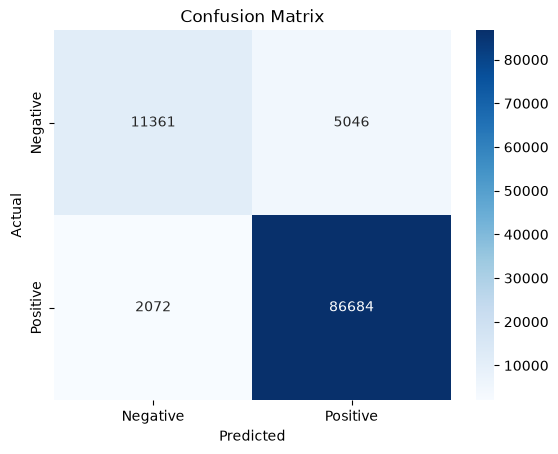

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
import joblib

joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
